# Hotel Booking Cancellation Prediction
#### By: Shaurya Aswal : [GitHub](https://github.com/Shaurya-aswal)

## Problem Statement

In recent years, the hotel industry has undergone major changes, with a large portion of reservations now being made through third-party platforms such as Booking.com. These Online Travel Agencies (OTAs) have made flexible cancellation policies a key part of their marketing strategy, encouraging customers to prefer bookings with free cancellation options. As a result, hotel booking cancellation rates have increased significantly over time, creating challenges for hotels and OTAs alike.

The growing number of cancellations makes it difficult for hotels to accurately predict occupancy levels and manage revenue efficiently. Hotels often face losses due to empty rooms, while OTAs may also bear financial responsibility through services that guarantee reservation payments when cancellations occur and replacement guests cannot be found. Therefore, booking cancellations create a serious financial burden across the hospitality industry.

Apart from financial losses, cancellations also create operational difficulties such as improper staffing, inefficient room management, and service disruptions. These issues can negatively affect customer experience and lead to poor online reviews. Since many travelers rely heavily on online ratings and reviews before selecting a hotel, maintaining customer satisfaction has become extremely important for hotel businesses. Poor service experiences caused by inaccurate booking forecasts can directly impact hotel occupancy and overall revenue.

Understanding which reservations are more likely to be canceled can help hotels improve planning and decision-making. Certain booking characteristics, such as long lead times or extended stays, are often associated with higher cancellation probabilities. Analyzing customer behavior and booking patterns can therefore provide valuable insights into why cancellations occur.

To address this problem, this project uses a real-world hotel booking dataset to perform customer segmentation analysis and identify meaningful customer groups based on booking behavior. In addition, a machine learning classification model will be developed to predict whether a reservation is likely to be canceled. The final model can help hotels make better operational decisions, reduce revenue loss, optimize resource management, and improve overall business performance.


## Executive Summary

Our goal is to build a model able to classify a booking as canceled or not canceled. In order to do so, we used data from the [Hotel Booking Demand Datasets](https://www.sciencedirect.com/science/article/pii/S2352340918315191). The dataset provides data from real bookings scheduled to arrive between July, 1st 2015 and August, 31st 2017 from two hotels in Portugal (a resort in the Algarve region (H1) and a hotel in the city of Lisbon (H2)). Booking data from both hotels share the same structure, with 31 variables describing the 40,060 observations of H1 and 79,330 observations of H2. For a detailed list and description of those variables refer to the [data dictionary](#Data-Dictionary).   
The two hotel datasets were merged into one main dataframe. The dataframe was then cleaned making sure to address any null values, reformat certain features, and engineer new ones. Exploratory analysis included analysis of the cancellation target variable and its relation with other features. Data visualisation tools were used to identify trends and valuable insights from those analysis.

## Loading Data


### Library Imports

In [ ]:
import pandas as pd
import numpy as np
from missingno import matrix
import pytimetk as tk


import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score

### Hotel Data Imports

Data gathered from the [Hotel Booking Demand Datasets](https://www.sciencedirect.com/science/article/pii/S2352340918315191).  
The data contains "two datasets with hotel demand data. One of the hotels (H1) is a resort hotel and the other is a city hotel (H2). Both datasets share the same structure, with 31 variables describing the 40,060 observations of H1 and 79,330 observations of H2. Each observation represents a hotel booking. Both datasets comprehend bookings due to arrive between the 1st of July of 2015 and the 31st of August 2017, including bookings that effectively arrived and bookings that were canceled."

In [3]:
h1 = pd.read_csv('H1.csv')
h1.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
h1.shape

(40060, 31)

In [5]:
h2 = pd.read_csv('H2.csv')
h2.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0.0,...,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03
1,1,88,2015,July,27,1,0,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30
3,1,92,2015,July,27,1,2,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23
4,1,100,2015,July,27,2,0,2,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02


In [6]:
h2.shape

(79330, 31)

In order to answer our problem statement, we need to combine information from both hotels into one dataframe.  
In order to retain information about which hotel each booking belongs to, we need to add a column recording the hotel associated with the booking. In order to make it easier for modeling later on, the same column `is_h1` will be added to both datasets. Bookings belonging to hotel 1 will have a value of `1` while bookings belonging to hotel 2 will have a value of `0` for this feature.

In [7]:
# Adding a column to h1 to record that bookings belong to hotel 1:
h1['is_h1'] = 1

# Adding a column to h2 to record that bookings do not belong to hotel 1 (and therefore belong to hotel 2):
h2['is_h1'] = 0

In [15]:
# Combining the two datasets:
df = pd.concat(objs = [h1, h2], axis = 0)

# Resetting the index
df.reset_index(drop = True, inplace=True)
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,is_h1
0,0,342,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,1
1,0,737,2015,July,27,1,0,0,2,0.0,...,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,1
2,0,7,2015,July,27,1,0,1,1,0.0,...,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,0,13,2015,July,27,1,0,1,1,0.0,...,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,0,14,2015,July,27,1,0,2,2,0.0,...,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,1


In [16]:
df.shape

(119390, 32)

The final dataset contains 32 features and 119,390 observations.

### Data Dictionary


|**Feature Name**|**Type**|**Description**|
|:---|:---|:---|
|ADR|Float|Average Daily Rate. Calculated by dividing the sum of all lodging transactions by the total number of staying nights.|
|Adults|Integer|Number of adults.|
|Agent|Categorical|ID of the travel agency that made the booking.|
|ArrivalDateDayOfMonth|Integer|Day of the month of the arrival date.|
|ArrivalDateMonth|Categorical|Month of arrival date with 12 categories: “January” to “December”.|
|ArrivalDateWeekNumber|Integer|Week number of the arrival date.|
|ArrivalDateYear|Integer|Year of arrival date.|
|AssignedRoomType|Categorical|Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.|
|Babies|Integer|Number of babies.|
|BookingChanges|Integer|Number of changes/amendments made to the booking from the moment the booking was entered on the Property Management System until the moment of check-in or cancellation. Calculated by adding the number of unique iterations that change some of the booking attributes, namely: persons, arrival date, nights, reserved room type or meal.|
|Children|Integer|Number of children. Sum of both payable and non-payable children.|
|Company|Categorical|ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons.|
|Country|Categorical|Country of origin. Categories are represented in the International Standards Organization (ISO) 3155–3:2013 format.|
|CustomerType|Categorical|Type of booking, assuming one of four categories: Contract (when the booking has an allotment or other type of contract associated to it), Group (when the booking is associated to a group), Transient (when the booking is not part of a group or contract, and is not associated to other transient booking), and Transient-party (when the booking is transient, but is associated to at least other transient booking).|
|DaysInWaitingList|Integer|Number of days the booking was in the waiting list before it was confirmed to the customer. Calculated by subtracting the date the booking was confirmed to the customer from the date the booking entered on the Property Management System.|
|DepositType|Categorical|Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories: No Deposit (no deposit was made), Non Refund (a deposit was made in the value of the total stay cost), and Refundable (a deposit was made with a value under the total cost of stay). Value calculated based on the payments identified for the booking in the transaction (TR) table before the booking׳s arrival or cancellation date. In case no payments were found the value is “No Deposit”. If the payment was equal or exceeded the total cost of stay, the value is set as “Non Refund”. Otherwise the value is set as “Refundable”.|
|DistributionChannel|Categorical|Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”.|
|IsCanceled|Integer|Value indicating if the booking was canceled (1) or not (0).|
|IsRepeatedGuest|Integer|Value indicating if the booking name was from a repeated guest (1) or not (0). Variable created by verifying if a profile was associated with the booking customer. If so, and if the customer profile creation date was prior to the creation date for the booking on the Property Management System database it was assumed the booking was from a repeated guest.|
|LeadTime|Integer|Number of days that elapsed between the entering date of the booking into the Property Management System and the arrival date. Calculated by subtracting the entering date from the arrival date.|
|MarketSegment|Categotical|Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”.|
|Meals|Categorical|Type of meal booked. Categories are presented in standard hospitality meal packages: Undefined/SC (no meal package), BB (Bed & Breakfast), HB (Half board: breakfast and one other meal – usually dinner), and FB (Full board: breakfast, lunch and dinner).|
|PreviousBookingsNotCanceled|Integer|Number of previous bookings not canceled by the customer prior to the current booking. In case there was no customer profile associated with the booking, the value is set to 0. Otherwise, the value is the number of bookings with the same customer profile created before the current booking and not canceled.|
|PreviousCancellations|Integer|Number of previous bookings that were canceled by the customer prior to the current booking. In case there was no customer profile associated with the booking, the value is set to 0. Otherwise, the value is the number of bookings with the same customer profile created before the current booking and canceled.|
|RequiredCarParkingSpaces|Integer|Number of car parking spaces required by the customer.|
|ReservationStatus|Categorical|Reservation last status, assuming one of three categories: Canceled (booking was canceled by the customer), Check-Out (customer has checked in but already departed), No-Show (customer did not check-in and did inform the hotel of the reason why).
|ReservationStatusDate|Date|Date at which the last status was set. This variable can be used in conjunction with the `ReservationStatus` to understand when was the booking canceled or when did the customer checked-out of the hotel.|
|ReservedRoomType|Categorical|Code of room type reserved. Code is presented instead of designation for anonymity reasons.|
|StaysInWeekendNights|Integer|Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel. Calculated by counting the number of weekend nights from the total number of nights.|
|StaysInWeekNights|Integer|Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel. Calculated by counting the number of week nights from the total number of nights.|
|TotalOfSpecialRequests|Integer|Number of special requests made by the customer (e.g. twin bed or high floor).|

####Total no. of people cancel

### Cancellation Count Analysis

This code block calculates the total number and proportion of canceled bookings (`is_canceled` = 1) versus non-canceled bookings (`is_canceled` = 0) in the dataset. This gives a quick overview of the cancellation rate.

In [20]:
cancel_count = df["is_canceled"].value_counts().reset_index()
cancel_count.columns = ["is_canceled","n"]
cancel_count["prop"] = cancel_count["n"]/cancel_count["n"].sum()
cancel_count

,is_canceled,n,prop
0,0,75166,0.629584
1,1,44224,0.370416


### Average Daily Rate (ADR) and Stay Duration

Here, we calculate the average daily rate (ADR) charged to guests and the average total number of stay days. The `total_stay_days` is a new feature derived from `stays_in_weekend_nights` and `stays_in_week_nights`.

In [21]:
average_adr = df['adr'].mean()
df['total_stay_days'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
average_stay_days = df['total_stay_days'].mean()

print(f"Average Price (ADR) of Hotel: {average_adr:.2f}")
print(f"Average Number of Stay Days: {average_stay_days:.2f}")

Average Price (ADR) of Hotel: 101.83
Average Number of Stay Days: 3.43


### Quantifying Potential Revenue Loss from Cancellations

This calculation estimates the potential revenue lost due to cancellations by multiplying the number of canceled bookings by the average daily rate and the average number of stay days. This provides a tangible figure for the economic impact of cancellations.

In [22]:
total_cost = 44224 * average_adr * average_stay_days

In [23]:
print(float(total_cost))

15437135.36896795


## Data Cleaning

### Feature Format

Using Snake Case (stylized as snake_case) is the Python best practice. However, the dataset was provided using Camel Camel (stylized as CamelCase). We need reformat the names of all feature names into snake case. In addition, some features included superfluous spaces that should be removed.

In [17]:
# Creating a function to reformat the feature names:
import re
def camel_to_snake(name):
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', name).lower()
# Function from https://stackoverflow.com/questions/1175208/elegant-python-function-to-convert-camelcase-to-snake-case

In [18]:
# Reformating the feature names:
df.columns = df.columns.map(camel_to_snake)

In [19]:
# Removing spaces:
features = ['meal','agent', 'company']
for feature in features:
    df[feature] = df[feature].str.strip()

### DATA PREPROCESSING

This section prepares the data for modeling by creating new features, handling missing values, and transforming categorical variables.

### Creating a Working DataFrame

We create a copy of the original DataFrame to perform preprocessing steps without altering the initial `df`.

In [24]:
cancel_df = df.copy()

### Adding New Features

Several new features are engineered to potentially improve model performance:
- `total_stay_days`: Sum of weekend and week nights.
- `total_people`: Sum of adults, children, and babies.
- `different_room_assigned`: A binary indicator (1 if assigned room type differs from reserved, 0 otherwise) which might suggest a negative guest experience or an operational issue.

######Adding new features

In [25]:
cancel_df['total_stay_days'] = cancel_df['stays_in_weekend_nights'] + cancel_df['stays_in_week_nights']


In [26]:
cancel_df["total_people"] = cancel_df["adults"] + cancel_df["children"] + cancel_df["babies"]

In [27]:
cancel_count["different_room_assigned"] = (cancel_df["assigned_room_type"] != cancel_df["reserved_room_type"]).astype(int)

In [28]:
cancel_df.drop(columns=['stays_in_weekend_nights',
                        'stays_in_week_nights',
                        "adults",
                        "children",
                        "babies",
                        "assigned_room_type",
                        "reserved_room_type"
                ], inplace=True, errors='ignore')

### Glimpse of the DataFrame after Feature Engineering and Dropping Columns

This `glimpse()` function (from `pytimetk`) provides a summary of the DataFrame's structure, column types, and a preview of data, confirming the changes made.

In [29]:
cancel_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119390 rows of 27 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
arrival_date_year:               int64             [2015, 2015, 2015, 20 ...
arrival_date_month:              object            ['July', 'July', 'Jul ...
arrival_date_week_number:        int64             [27, 27, 27, 27, 27,  ...
arrival_date_day_of_month:       int64             [1, 1, 1, 1, 1, 1, 1, ...
meal:                            object            ['BB', 'BB', 'BB', 'B ...
country:                         object            ['PRT', 'PRT', 'GBR', ...
market_segment:                  object            ['Direct', 'Direct',  ...
distribution_channel:            object            ['Direct', 'Direct',  ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bo

###Fixing missing data

<Axes: >

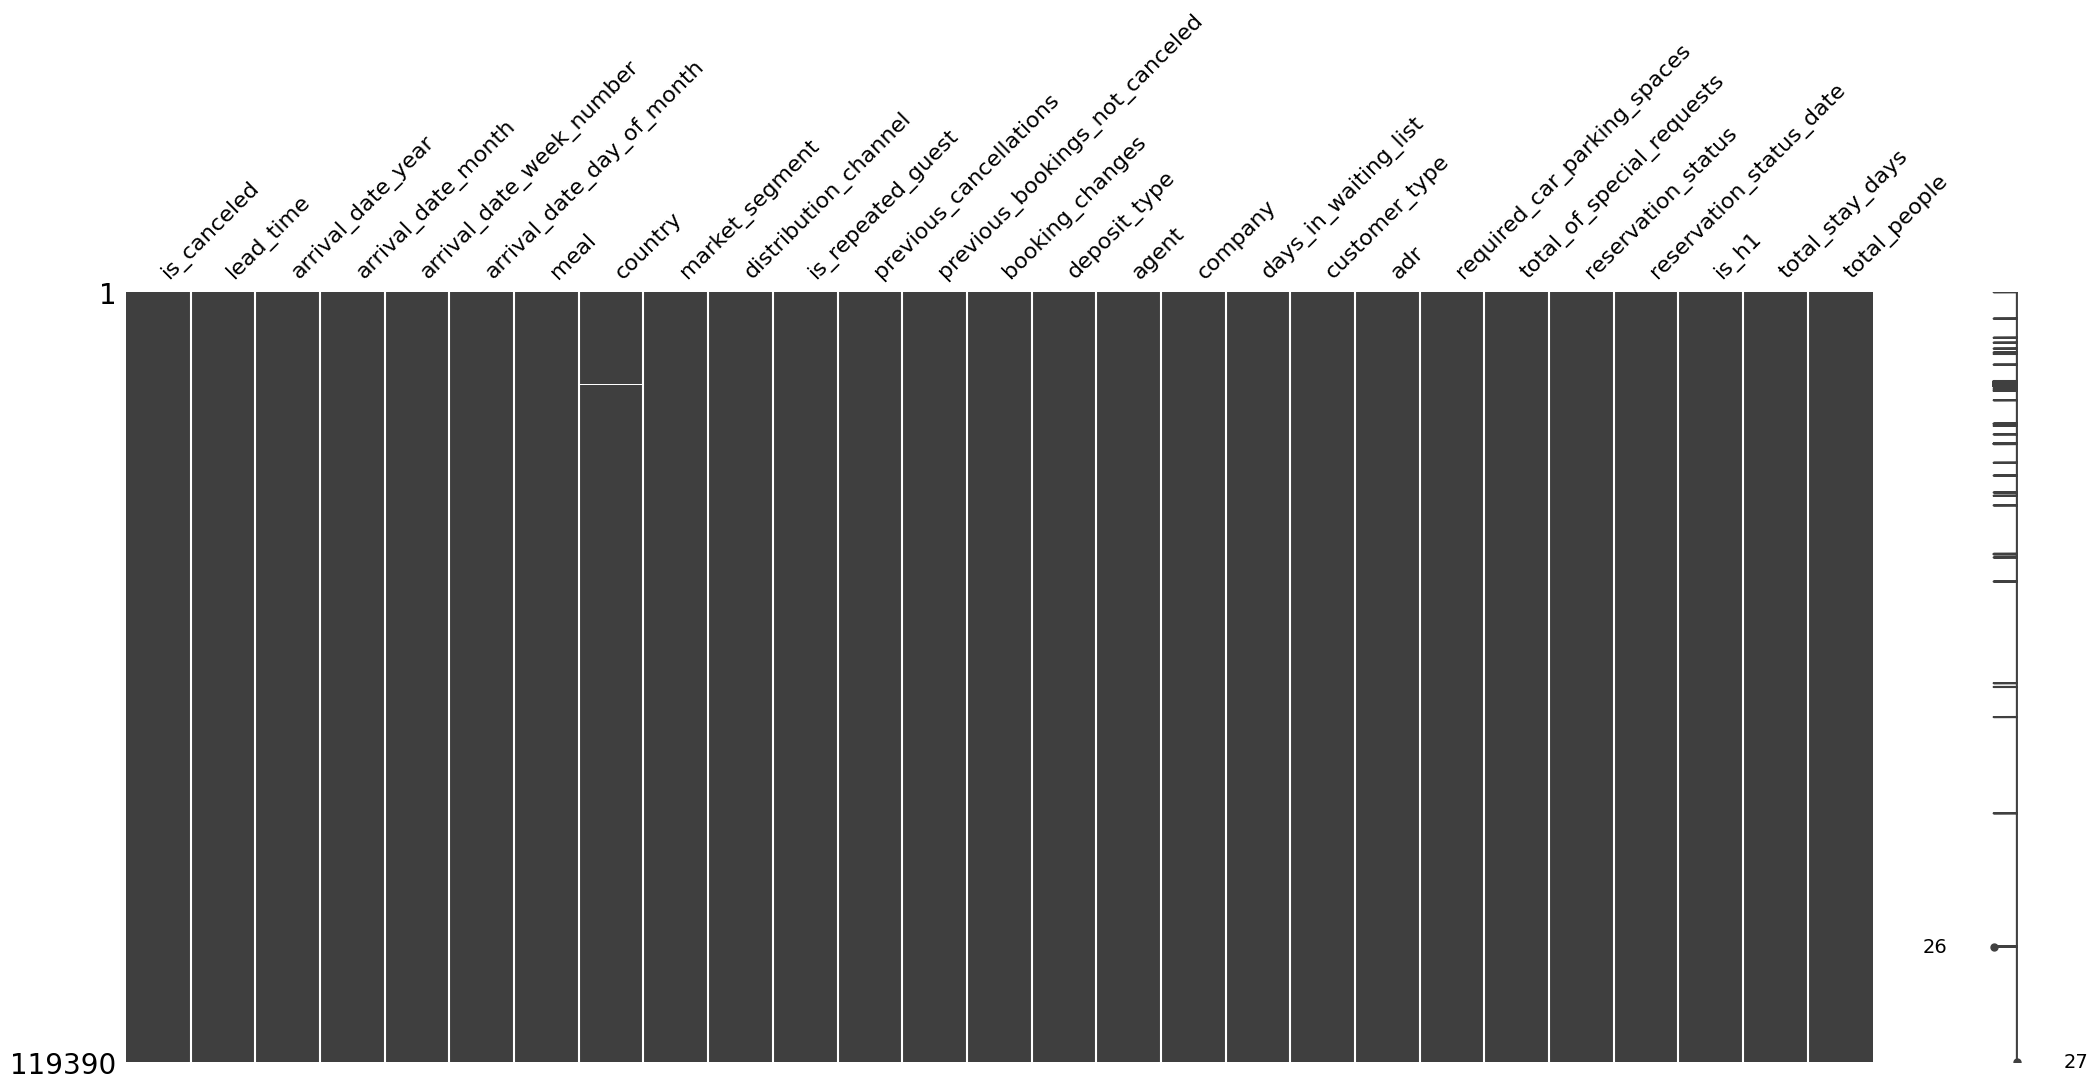

In [30]:
matrix(cancel_df)

In [31]:
country_count = cancel_df["country"].value_counts().reset_index()
country_count.columns = ["country","n"]
country_count["prop"] = country_count["n"]/country_count["n"].sum()
country_count

,country,n,prop
0,PRT,48590,0.408656
1,GBR,12129,0.102008
2,FRA,10415,0.087593
3,ESP,8568,0.072059
4,DEU,7287,0.061286
...,...,...,...
172,MRT,1,0.000008
173,KIR,1,0.000008
174,SDN,1,0.000008
175,ATF,1,0.000008


In [32]:
cancel_df["country"] = cancel_df["country"].fillna("PRT")

In [33]:
cancel_df.dropna(inplace=True)


In [34]:
cancel_df = cancel_df.drop(columns=["agent", "company"])

In [35]:
cancel_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 25 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
arrival_date_year:               int64             [2015, 2015, 2015, 20 ...
arrival_date_month:              object            ['July', 'July', 'Jul ...
arrival_date_week_number:        int64             [27, 27, 27, 27, 27,  ...
arrival_date_day_of_month:       int64             [1, 1, 1, 1, 1, 1, 1, ...
meal:                            object            ['BB', 'BB', 'BB', 'B ...
country:                         object            ['PRT', 'PRT', 'GBR', ...
market_segment:                  object            ['Direct', 'Direct',  ...
distribution_channel:            object            ['Direct', 'Direct',  ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bo

In [37]:
canceled_df = cancel_df.copy()

In [43]:
df_binarized = canceled_df.binarize()

In [47]:
df_binarized['is_canceled'] = canceled_df['is_canceled']

In [48]:
df_correlate = df_binarized.correlate(target="is_canceled__1")

In [49]:
df_binarized.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 105 columns
lead_time__0.0_18.0:                     int64             [0, 0, 1, 1,  ...
lead_time__18.0_69.0:                    int64             [0, 0, 0, 0,  ...
lead_time__69.0_160.0:                   int64             [0, 0, 0, 0,  ...
lead_time__160.0_737.0:                  int64             [1, 1, 0, 0,  ...
arrival_date_week_number__1.0_16.0:      int64             [0, 0, 0, 0,  ...
arrival_date_week_number__16.0_28.0:     int64             [1, 1, 1, 1,  ...
arrival_date_week_number__28.0_38.0:     int64             [0, 0, 0, 0,  ...
arrival_date_week_number__38.0_53.0:     int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__1.0_8.0:      int64             [1, 1, 1, 1,  ...
arrival_date_day_of_month__8.0_16.0:     int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__16.0_23.0:    int64             [0, 0, 0, 0,  ...
arrival_date_day_of_month__23.0_31.0:    int64             [0, 0, 0, 0,  ...
adr__-6.4_

In [46]:
df_correlate.head(10)

,feature,bin,correlation
23,is_canceled,1,1.000000
22,is_canceled,0,-1.000000
98,reservation_status,Check-Out,-1.000000
97,reservation_status,Canceled,0.978433
82,deposit_type,Non Refund,0.481488
81,deposit_type,No Deposit,-0.477942
56,country,PRT,0.331560
71,previous_cancellations,1,0.274606
70,previous_cancellations,0,-0.270962
0,lead_time,0.0_18.0,-0.270429


In [51]:
df_correlate.plot_correlation_funnel()

In [55]:
new_df = canceled_df.drop(columns=["reservation_status"])

###selecting important columns

In [56]:
new_df = new_df[["is_canceled","deposit_type","country","previous_cancellations","lead_time","total_of_special_requests","market_segment","required_car_parking_spaces","booking_changes","distribution_channel","customer_type","previous_bookings_not_canceled","is_repeated_guest"]]

In [57]:
new_df["country_prt"] = (new_df["country"]=="PRT").astype(int)
new_df["country_other"] = (new_df["country"]!="prt").astype(int)

In [58]:
new_df.drop(columns=["country"],inplace=True)

In [59]:
new_df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 14 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type:                    object            ['No Deposit     ', ' ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       int64             [342, 737, 7, 13, 14, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
market_segment:                  object            ['Direct', 'Direct',  ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
distribution_channel:            object            ['Direct', 'Direct',  ...
customer_type:                   object            ['Transient', 'Transi ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt

## EDA

### Target Variable: Cancellation

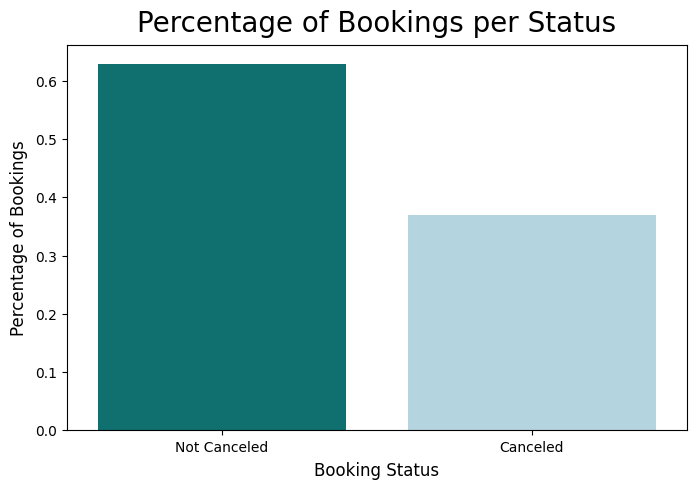

In [64]:
# Visualizing the percentage of canceled vs not canceled bookings:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.title("Percentage of Bookings per Status", fontsize = 20, pad = 10)
sns.barplot(x=df['is_canceled'].unique(), y=df['is_canceled'].value_counts(normalize=True), palette=['teal', 'lightblue'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 5)
plt.ylabel("Percentage of Bookings", fontsize = 12, labelpad = 5)
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled']);

**Interpretation:** 37% of bookings were canceled. This is line with the 40% cancellation rate reported by the [D-Edge Study](https://www.d-edge.com/how-online-hotel-distribution-is-changing-in-europe/).

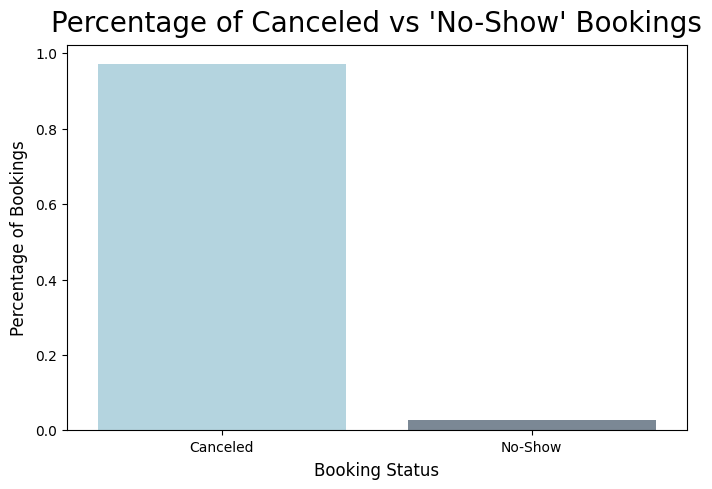

In [65]:
# Visualizing the percentage of bookings canceled prior to arrival:
plt.figure(figsize=(8,5))
plt.title("Percentage of Canceled vs 'No-Show' Bookings", fontsize = 20, pad = 10)
sns.barplot(x=df[df['is_canceled']==1]['reservation_status'].unique(), y=df[df['is_canceled']==1]['reservation_status'].value_counts(normalize=True), palette=['lightblue', 'lightslategrey'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 5)
plt.ylabel("Percentage of Bookings", fontsize = 12, labelpad = 5);

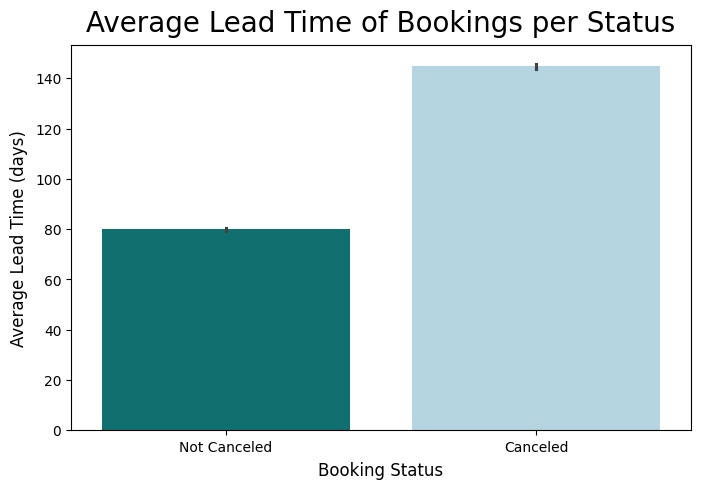

In [67]:
# Visualizing the average lead time for canceled and not canceled bookings:
plt.figure(figsize=(8,5))
plt.title("Average Lead Time of Bookings per Status", fontsize = 20, pad = 10)
sns.barplot(x=df['is_canceled'], y=df['lead_time'], palette=['teal', 'lightblue'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 5)
plt.ylabel("Average Lead Time (days)", fontsize = 12, labelpad = 5)
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled']);

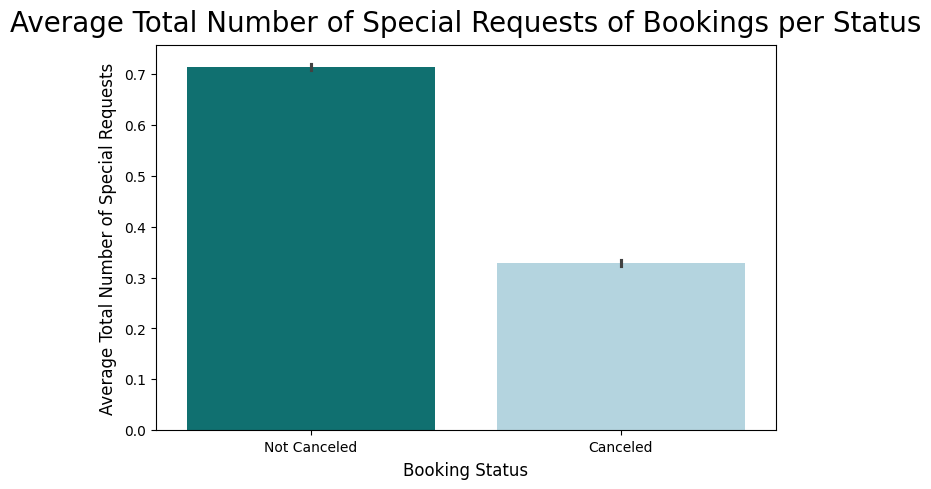

In [68]:
# Visualizing the total number of special requests for canceled and not canceled bookings:
plt.figure(figsize=(8,5))
plt.title("Average Total Number of Special Requests of Bookings per Status", fontsize = 20, pad = 10)
sns.barplot(x=df['is_canceled'], y=df['total_of_special_requests'], palette=['teal', 'lightblue'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 5)
plt.ylabel("Average Total Number of Special Requests", fontsize = 12, labelpad = 5)
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled']);

**Interpretation:** Customers who cancel their bookings make on average fewer special requests. Potential reasons why were discussed above.

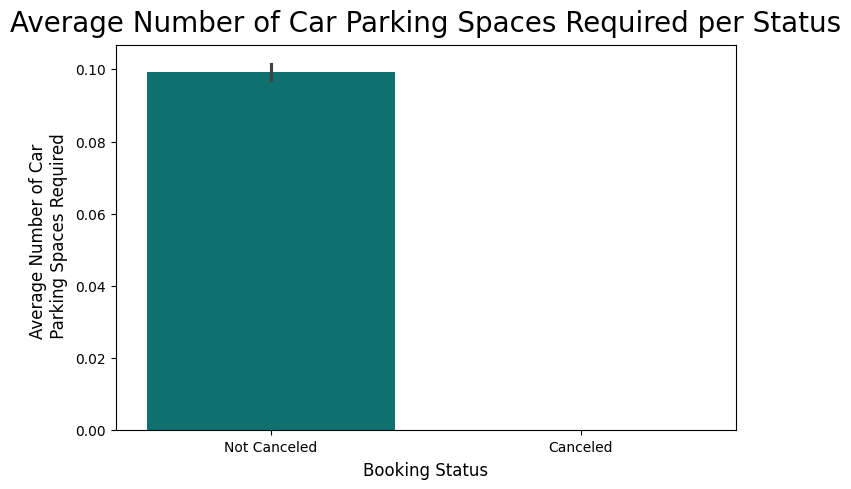

In [69]:
# Visualizing the total number of requested parking spaces for canceled and not canceled bookings:
plt.figure(figsize=(8,5))
plt.title("Average Number of Car Parking Spaces Required per Status", fontsize = 20, pad = 10)
sns.barplot(x=df['is_canceled'], y=df['required_car_parking_spaces'], palette=['teal', 'lightblue'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 5)
plt.ylabel("Average Number of Car \n Parking Spaces Required", fontsize = 12, labelpad = 5)
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled']);

**Interpretation:** On average, customers who do not cancel their bookings tend to require more parking spaces. Similarly to the number of special requests, it would make sense that the more a customer engages with the hotel (by putting in a  request for a parking spot), the less likely they are to cancel. It is also fair to think that by the time a guest is thinking about where they will park their car, they are most likely pretty commited to their destination. Finally, thinking about this from the hotel perpective, it is possible that not many hotels around have a parking. As a result, the need for a parking space would limit the customer in their hotel options and make them less likely to cancel. More information would be required from the hotel directly to confirm this theory. However, if true, this suggests that adding parking spaces could be a way to help reduce cancellations.

##casual hypothesis

######Q1) will reducing lead time reduce cancellation??

In [71]:
lead_time_df = new_df[["is_canceled","lead_time"]].copy()

In [72]:
lead_time_df["lead_time_binned"] = pd.qcut(lead_time_df["lead_time"],q=4,duplicates="drop")

In [73]:
lead_time_dummy = pd.get_dummies(lead_time_df["lead_time_binned"],drop_first=True)

In [74]:
X = lead_time_dummy.astype(float)
Y = lead_time_df["is_canceled"].astype(float)

In [75]:
X = sm.add_constant(X)

In [76]:
model = sm.Logit(Y,X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.608661
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:               119386
Model:                          Logit   Df Residuals:                   119382
Method:                           MLE   Df Model:                            3
Date:                Tue, 12 May 2026   Pseudo R-squ.:                 0.07662
Time:                        09:12:49   Log-Likelihood:                -72666.
converged:                       True   LL-Null:                       -78695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7643      0.016   -108.441      0.000      -1.796      -1.732
(18.0, 69.0]     

####logistic regression produces log(odds)

In [77]:
np.exp(1.98) ## 160+ days - 7.2X risk of cancellation
np.exp(1.47) ## 69-160 days - 4.3X risk of cancellation
np.exp(1.18) ## 18-69 days - 3.25X risk of cancellation

np.float64(3.2543742028896707)

####consedering cofounders

In [78]:
df = new_df.copy()
df["lead_time"] = pd.qcut(lead_time_df["lead_time"],q=4,duplicates="drop")

In [79]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 14 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type:                    object            ['No Deposit     ', ' ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time:                       category          [Interval(160.0, 737. ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
market_segment:                  object            ['Direct', 'Direct',  ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
distribution_channel:            object            ['Direct', 'Direct',  ...
customer_type:                   object            ['Transient', 'Transi ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt

In [80]:
df = pd.get_dummies(df,drop_first=True)

In [81]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 27 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 0, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
deposit_type_Non Refund     :    bool              [False, False, False, ...
deposit_type_Refundable     :    bool              [False, False, False, ...
lead_time_(18.0, 69.0]:          bool              [False, False, False, ...
lead_time_(

In [82]:
for col in df.columns:
    if df[col].dtype == "bool":
      df[col] = df[col].astype(int)


In [83]:
df.glimpse()

<class 'pandas.core.frame.DataFrame'>: 119386 rows of 27 columns
is_canceled:                     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_cancellations:          int64             [0, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 0, 1, 1, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
booking_changes:                 int64             [3, 4, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 0, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
deposit_type_Non Refund     :    int64             [0, 0, 0, 0, 0, 0, 0, ...
deposit_type_Refundable     :    int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time_(18.0, 69.0]:          int64             [0, 0, 0, 0, 0, 0, 0, ...
lead_time_(

In [84]:
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

In [85]:
x_train = train_df.drop(columns=["is_canceled"])
y_train = train_df["is_canceled"]
x_test = sm.add_constant(test_df.drop(columns=["is_canceled"]))
y_test = test_df["is_canceled"]

In [86]:
Model = GLM(y_train,sm.add_constant(x_train),family=Binomial(),link=logit())
result = Model.fit_regularized(method = "elastic_net",alpha=0.01,L1_wt=1.0)

In [87]:
pred_prob= result.predict(x_test)
roc_auc = roc_auc_score(y_test,pred_prob)
print(roc_auc)

0.8563725832405129


In [88]:
pd.DataFrame(result.params)

,0
previous_cancellations,0.243115
total_of_special_requests,-0.529974
required_car_parking_spaces,-0.816411
booking_changes,-0.247128
previous_bookings_not_canceled,-0.123001
is_repeated_guest,0.000000
country_prt,0.787755
country_other,-1.161162
deposit_type_Non Refund,2.456508
deposit_type_Refundable,0.000000


In [90]:
np.exp(0.438781)
### if we see the lead_time for 160+ days = 0.438781 which is 1.55X risk of cancellation but it goes down from 7X

np.float64(1.5508156215745403)

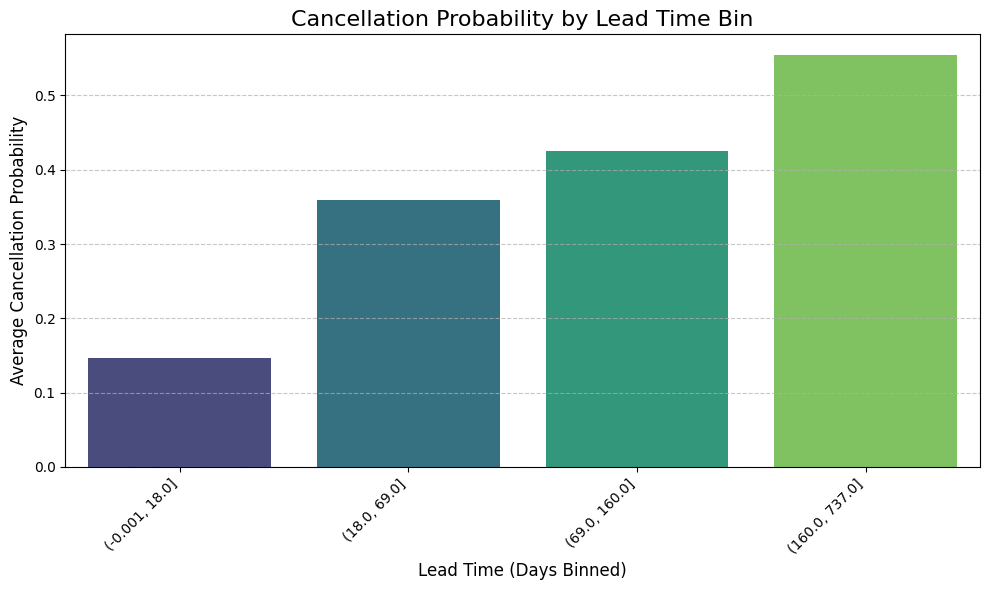

In [96]:


plt.figure(figsize=(10, 6))
sns.barplot(x='lead_time_binned', y='cancellation_probability', data=mean_cancellation_prob, palette='viridis')
plt.title('Cancellation Probability by Lead Time Bin', fontsize=16)
plt.xlabel('Lead Time (Days Binned)', fontsize=12)
plt.ylabel('Average Cancellation Probability', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion of Hotel Booking Cancellation Analysis

This project aimed to predict hotel booking cancellations and uncover factors influencing them, addressing a critical challenge for hotels and Online Travel Agencies (OTAs).

### 1. Data Preparation and Cleaning
We began by integrating booking data from two different hotels (H1: resort, H2: city), ensuring data consistency by converting feature names to `snake_case` and handling missing values. Crucially, we engineered new features like `total_stay_days` and `total_people` to capture more nuanced booking characteristics.

### 2. Exploratory Data Analysis (EDA) Insights
Initial EDA revealed significant cancellation rates (approximately 37%) in line with industry trends. Key observations included:
*   **Lead Time**: Bookings made further in advance had a higher likelihood of cancellation.
*   **Special Requests**: Fewer special requests correlated with an increased chance of cancellation.
*   **Parking Spaces**: Bookings requiring parking spaces were less likely to be canceled, suggesting higher commitment.

### 3. Causal Hypothesis: Lead Time and Cancellation
We specifically investigated the hypothesis: "Will reducing lead time reduce cancellation?" A simple logistic regression model, considering only binned lead times, showed that bookings with lead times over 160 days carried a significantly higher risk of cancellation (approximately 7.2 times more likely compared to very short lead times). This confirmed lead time as a strong predictor.

### 4. Predictive Modeling and Key Drivers
A more sophisticated **Generalized Linear Model (GLM)**, specifically a logistic regression with Elastic Net regularization, was developed using a broader set of features. This model achieved a respectable **ROC AUC score of 0.856**, demonstrating its ability to discriminate between canceled and non-canceled bookings.

The most impactful factors identified by this model were:
*   **Deposit Type**: Non-refundable deposits were strongly associated with cancellation, often indicating a booking that has already been canceled but still holds a value.
*   **Lead Time**: Even with other factors considered, longer lead times remained a significant risk factor, though the magnitude of risk decreased (e.g., 1.55 times risk for 160+ days lead time in the full model vs. 7.2X in the simple model, as other confounding factors were accounted for).
*   **Country**: Bookings from certain countries (e.g., Portugal) showed varying cancellation probabilities.
*   **Customer Engagement**: `total_of_special_requests` and `required_car_parking_spaces` both had negative coefficients, reinforcing the idea that higher guest engagement (more requests, need for parking) translates to lower cancellation risk.
*   **Previous Behavior**: `previous_cancellations` had a positive impact, suggesting past cancellation behavior is a good predictor of future cancellations.

### 5. Actionable Recommendations
Based on these findings, hotels can implement several strategies:
*   **Dynamic Pricing/Policies**: Adjust deposit requirements or offer incentives based on lead time, especially for long lead-time bookings.
*   **Targeted Engagement**: Proactively engage with guests who have minimal special requests or very long lead times to reinforce commitment.
*   **Personalized Offers**: Use insights from `previous_cancellations` and `customer_type` to tailor offers and communication.
*   **Operational Planning**: Use the model's predictions to better forecast occupancy, optimize staffing, and manage inventory, thereby reducing revenue loss and improving customer satisfaction.

In summary, this analysis provides a data-driven understanding of hotel booking cancellations, enabling more informed decision-making and proactive management of this critical business challenge.